# Coinbase Orderbook Analysis

## Overview

This notebook loads preprocessed Coinbase order book and trade data, then analyzes mid-price movement, spread and volume distributions, price-change behavior, heatmaps, and correlations.

## Data

The data comes from Coinbase market batches. `PRODUCT_ID` identifies the Coinbase market pair, and the filename timestamp is UTC. That timestamp anchors the batch date used by the `Time` column.

### Batch

Level 2:

- `level2-PRODUCT_ID-init-yyyymmdd.hhmmss.csv`
- `level2-PRODUCT_ID-updates-yyyymmdd.hhmmss.csv`

`init` represents the initial level 2 order book snapshot for the batch. `updates` contains level 2 order book changes after the initial snapshot.

Trade:

- `trade-PRODUCT_ID-yyyymmdd.hhmmss.csv`

`trade` contains executed market trades aligned to the same batch timestamp.

### Columns

`Price`, `Volume`, and `Side` describe price level, size, and bid/ask or buy/sell side depending on the file type.

`init`:

| Price | Volume | Side |
| - | - | - |

`updates`:

| Time | Price | Volume | Side |
| - | - | - | - |

`trade`:

| Time | Price | Volume | Side |
| - | - | - | - |

- `Time` is measured in seconds from midnight of the filename date.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "result":
    PROJECT_ROOT = PROJECT_ROOT.parent
RESULT_DIR = PROJECT_ROOT / "result"
if str(RESULT_DIR) not in sys.path:
    sys.path.insert(0, str(RESULT_DIR))

import support as sp

PREPROCESS_PATH = PROJECT_ROOT / "data" / "preprocessed"
ORDERBOOK_WINDOWS = [1, 5, 10, 30]
DISTRIBUTION_WINDOW = 1
BASE_WINDOW_FOR_CORRELATION = 1
PRICE_CHANGE_HORIZONS = [1, 5, 10, 30]
VARIANCE_WINDOWS = [60, 300, 600]

orderbook_by_window, trade_by_window = sp.load_and_validate_data(
    PREPROCESS_PATH,
    ORDERBOOK_WINDOWS,
    ORDERBOOK_WINDOWS,
    BASE_WINDOW_FOR_CORRELATION,
)

Orderbook windows: [1, 5, 10, 30]
Trade windows: [1, 5, 10, 30]


## Mid Price


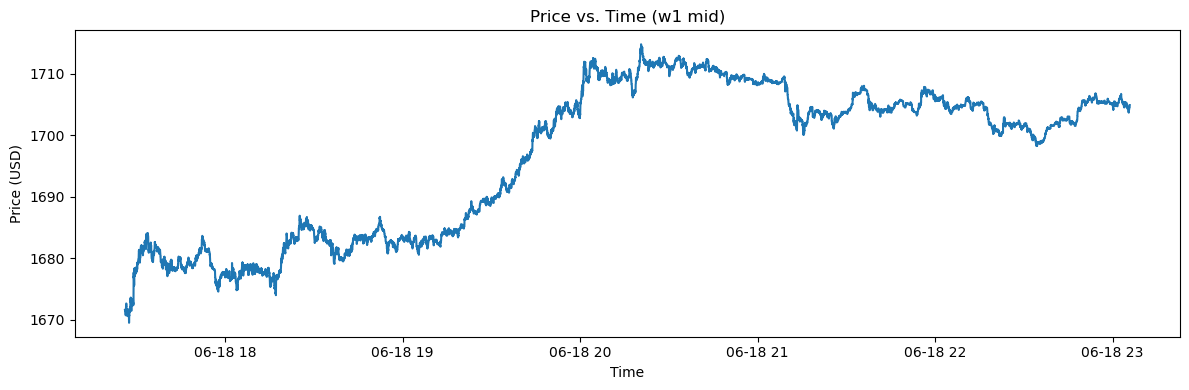

In [2]:
base_orderbook, mid_time, mid_price = sp.plot_mid_price(
    orderbook_by_window,
    BASE_WINDOW_FOR_CORRELATION,
)


### Price Change


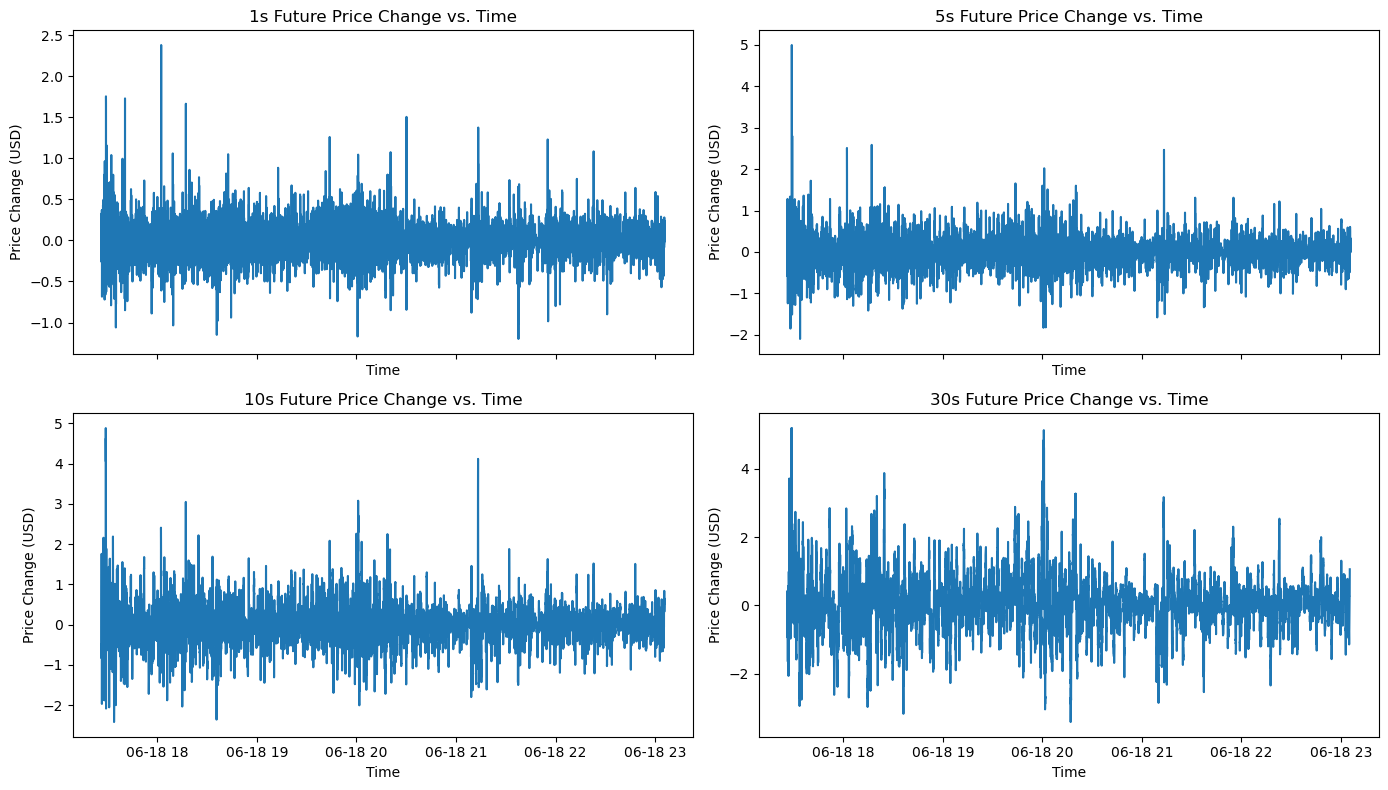

In [3]:
price_change_by_horizon = sp.plot_future_price_change(
    mid_time,
    mid_price,
    PRICE_CHANGE_HORIZONS,
)


### Price Change Average

This section computes the rolling average of future price change over each averaging window. In this sample, the averages stay close to 0, and longer averaging windows appear to pull the rolling average closer to 0.


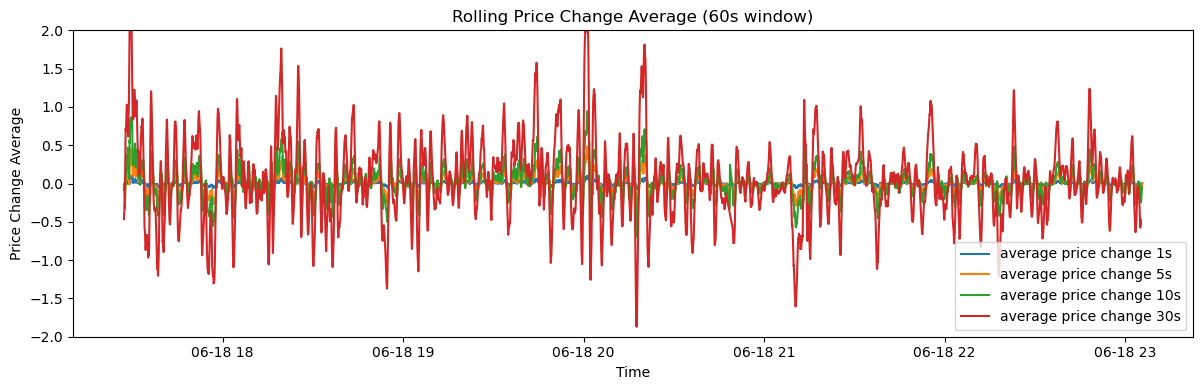

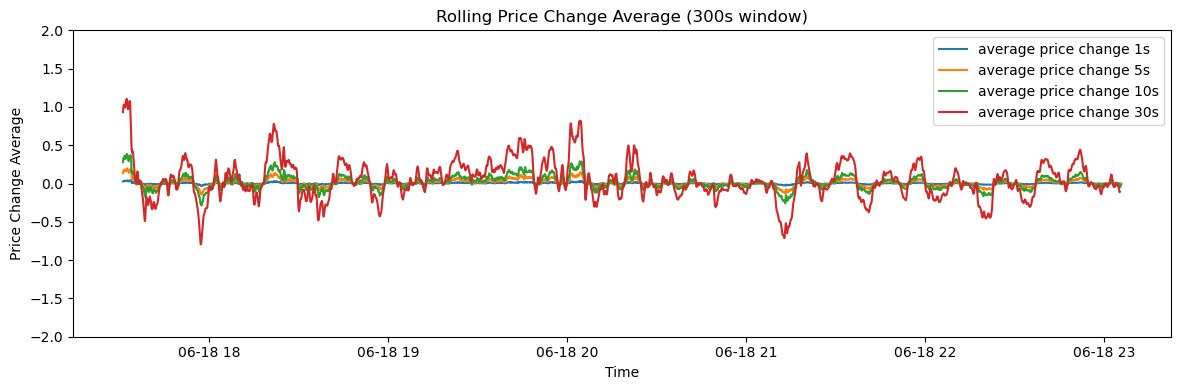

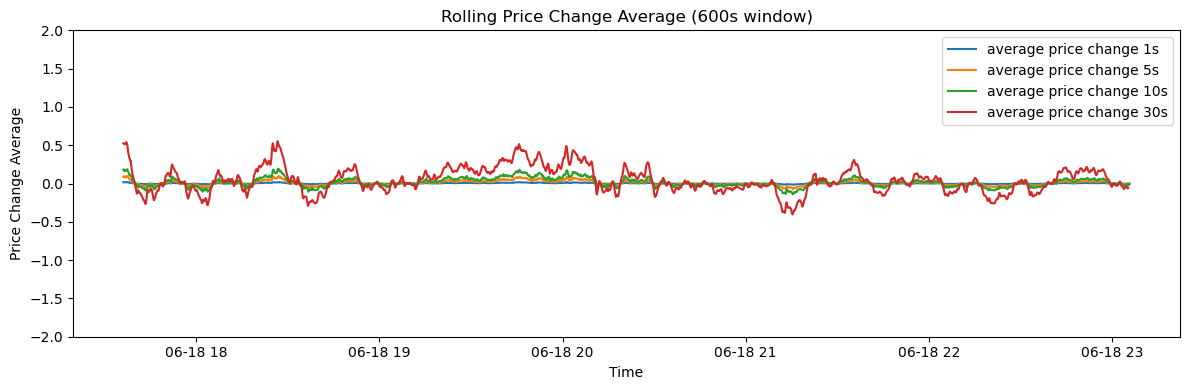

In [4]:
average_by_config = sp.plot_rolling_price_change_average(
    price_change_by_horizon,
    PRICE_CHANGE_HORIZONS,
    VARIANCE_WINDOWS,
)


### Price Change Variance

Because the mean of price_change is close to 0, this section estimates the rolling variance by computing the rolling expectation of `price_change^2`.

The plot suggests volatility clustering: as the variance window becomes longer, variance does not appear only as a sharp isolated peak, but tends to remain elevated for a period of time.


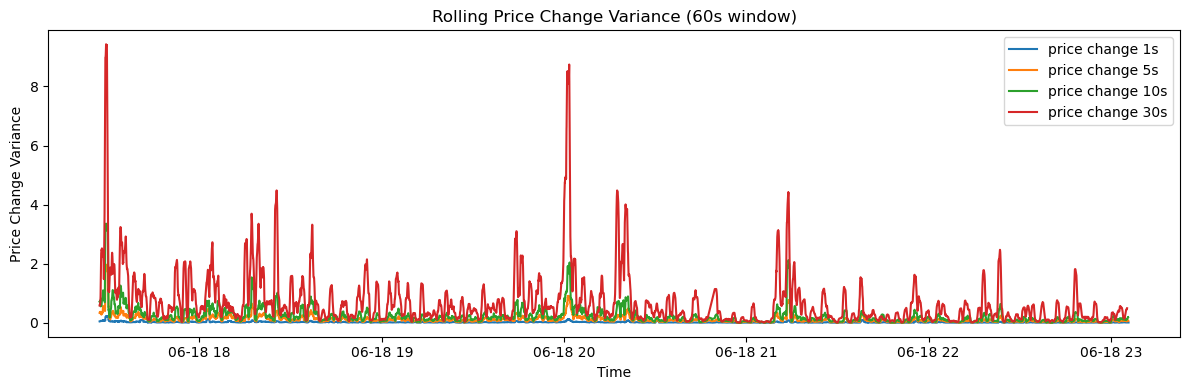

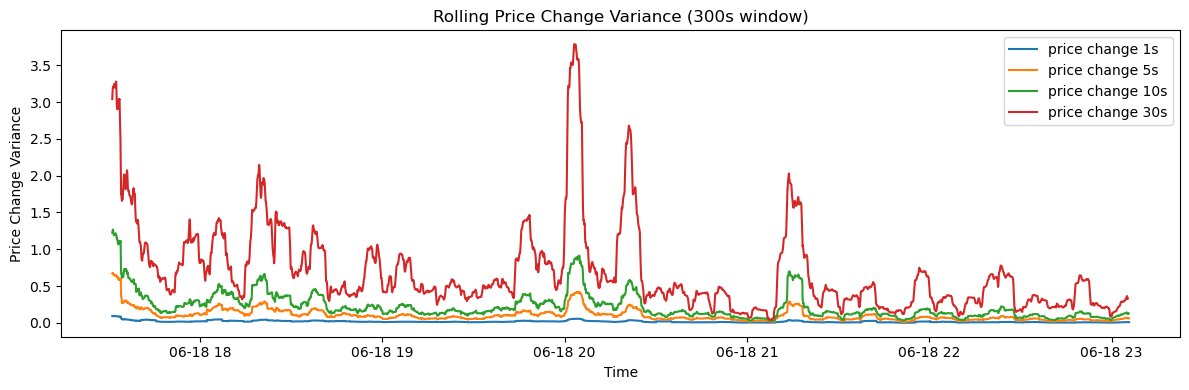

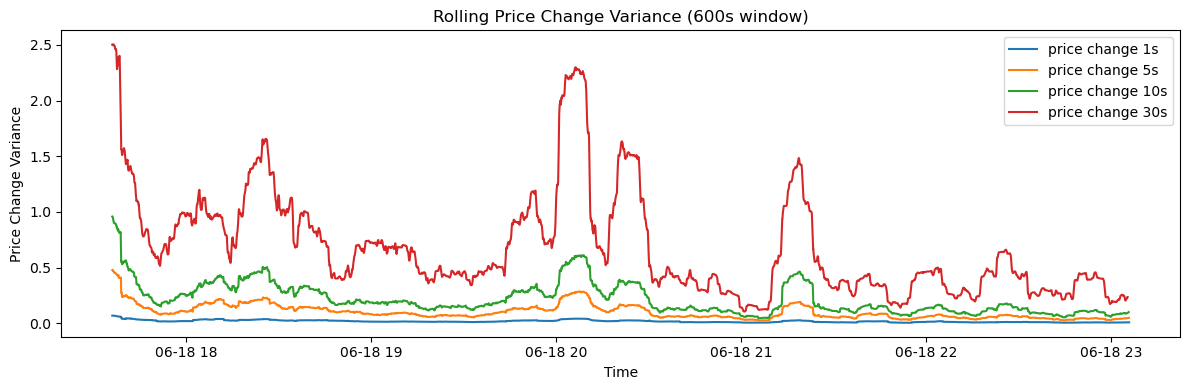

In [5]:
variance_by_config = sp.plot_rolling_price_change_variance(
    price_change_by_horizon,
    PRICE_CHANGE_HORIZONS,
    VARIANCE_WINDOWS,
)


## Distribution


### Spread

For small spreads, this section fits a normal distribution, although the fit does not appear very tight. On the log-log scale, the distribution shows an approximately linear tail, suggesting a power-law fat tail.


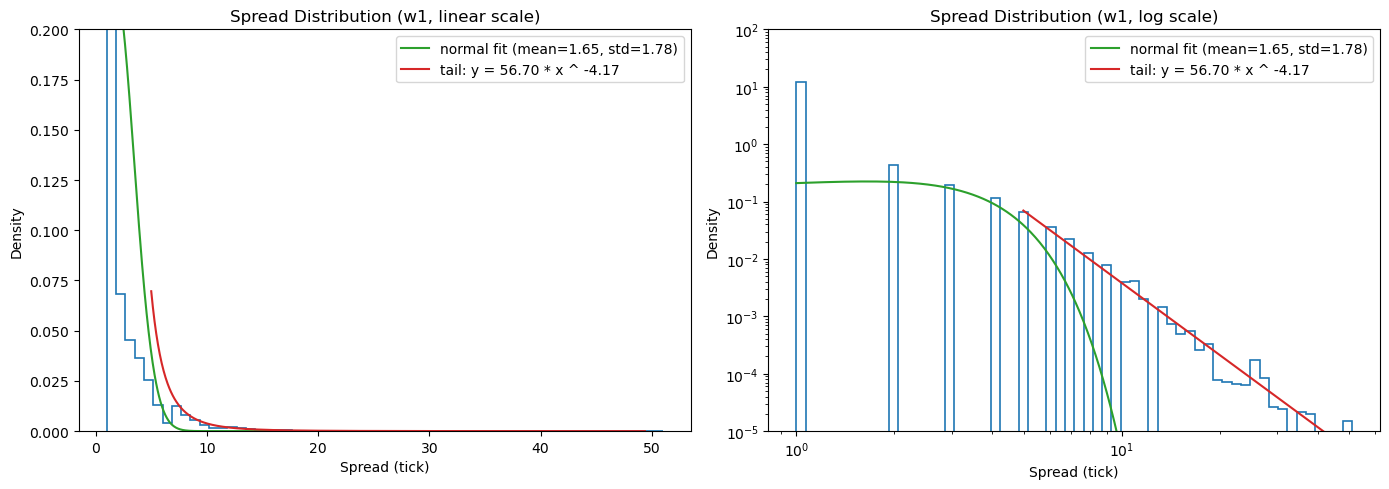

In [6]:
window_seconds = DISTRIBUTION_WINDOW
spread_normal_fit_config = {
    "label": "",
    "x_min": 0,
    "x_max": 20,
    "color": "tab:green",
}
spread_power_law_fit_configs = [
    {"label": "tail", "start": 4, "end": 29, "color": "tab:red"},
]
spread_hist_bins = 60

spread_distribution_result = sp.plot_spread_distribution(
    orderbook_by_window,
    window_seconds,
    spread_normal_fit_config,
    spread_power_law_fit_configs,
    spread_hist_bins,
)


### Trade Volume

The trade volume distribution decays quickly in the first few bins. After that, it appears to split into two power-law regimes, with fitted slopes of approximately -0.5 and -2.4.


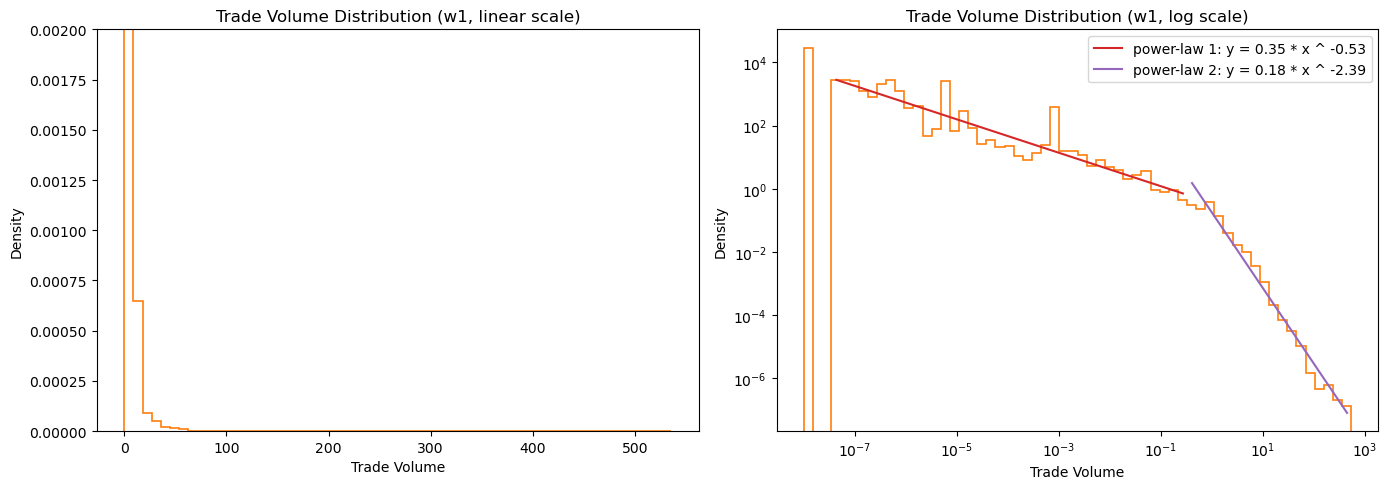

In [7]:
window_seconds = DISTRIBUTION_WINDOW
trade_volume_fit_configs = [
    {"label": "power-law 1", "start": 1, "end": 40, "color": "tab:red"},
    {"label": "power-law 2", "start": 40, "end": 58, "color": "tab:purple"},
]
trade_volume_hist_bins = 60

trade_volume_distribution_result = sp.plot_trade_volume_distribution(
    trade_by_window,
    window_seconds,
    trade_volume_fit_configs,
    trade_volume_hist_bins,
)


### Price Change

This section computes the distributions of price changes 1, 5, 10, and 30 seconds into the future. The plots suggest several patterns:

- As the time horizon increases, the center of the distribution appears closer to a normal distribution.
- The tails are fit with exponential curves; longer horizons appear to have slower tail decay.
- The positive and negative tails decay at different rates, which may reflect the market's directional price movement during the sample.


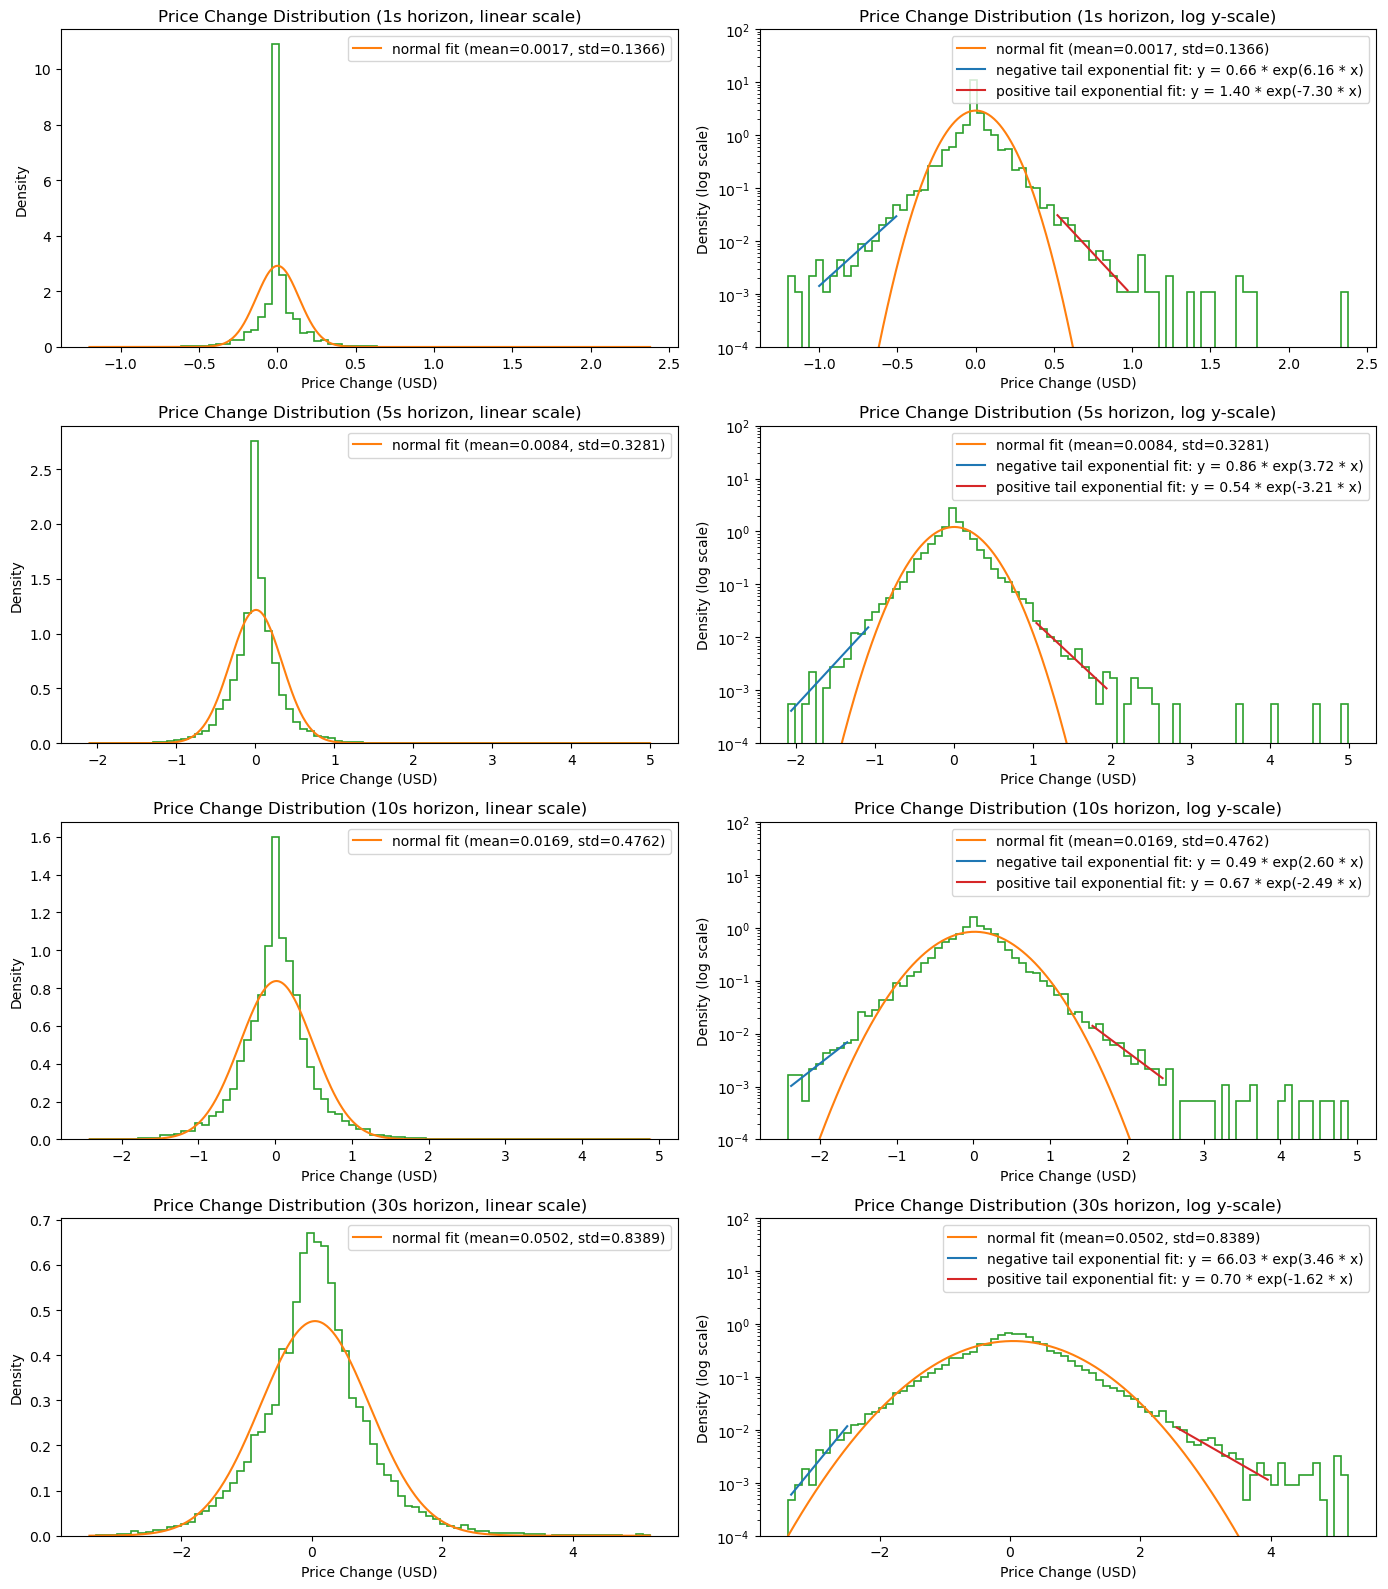

In [8]:
price_change_exponential_fit_configs = {
    1: [
        {"label": "negative tail", "x_min": -1, "x_max": -0.5, "color": "tab:blue"},
        {"label": "positive tail", "x_min": 0.5, "x_max": 1, "color": "tab:red"},
    ],
    5: [
        {"label": "negative tail", "x_min": -2.1, "x_max": -1, "color": "tab:blue"},
        {"label": "positive tail", "x_min": 1, "x_max": 2, "color": "tab:red"},
    ],
    10: [
        {"label": "negative tail", "x_min": -2.4, "x_max": -1.6, "color": "tab:blue"},
        {"label": "positive tail", "x_min": 1.5, "x_max": 2.5, "color": "tab:red"},
    ],
    30: [
        {"label": "negative tail", "x_min": -3.4, "x_max": -2.4, "color": "tab:blue"},
        {"label": "positive tail", "x_min": 2.5, "x_max": 4, "color": "tab:red"},
    ],
}
price_change_hist_bins = 80

price_change_distribution_by_horizon = sp.plot_price_change_distribution(
    price_change_by_horizon,
    PRICE_CHANGE_HORIZONS,
    price_change_exponential_fit_configs,
    price_change_hist_bins,
)


## Heatmap: $V_{opp}$ vs. $V_{near}$

### Average Executed Ratio

This section combines bid-side and ask-side observations by expressing each case in terms of near-side and opposite-side volume. It then computes the cumulative trade volume that consumes the near-side queue over the 1, 5, 10, and 30 second horizons, divides it by the top-5 near-side queue volume at the start of the interval, and clips the resulting `executed_ratio` at 1. The binned average can be interpreted as an empirical fill probability proxy.

The heatmaps suggest:

- Longer horizons generally produce higher executed ratios, which is consistent with intuition.
- Regions with smaller near-side size and larger opposite-side size tend to have higher executed ratios; the reverse tends to have lower executed ratios, matching the expected behavior of fill probability.
- The 5-10 second range appears to be a useful statistical window in this sample: it is less saturated than 30 seconds and more structured than 1 second.


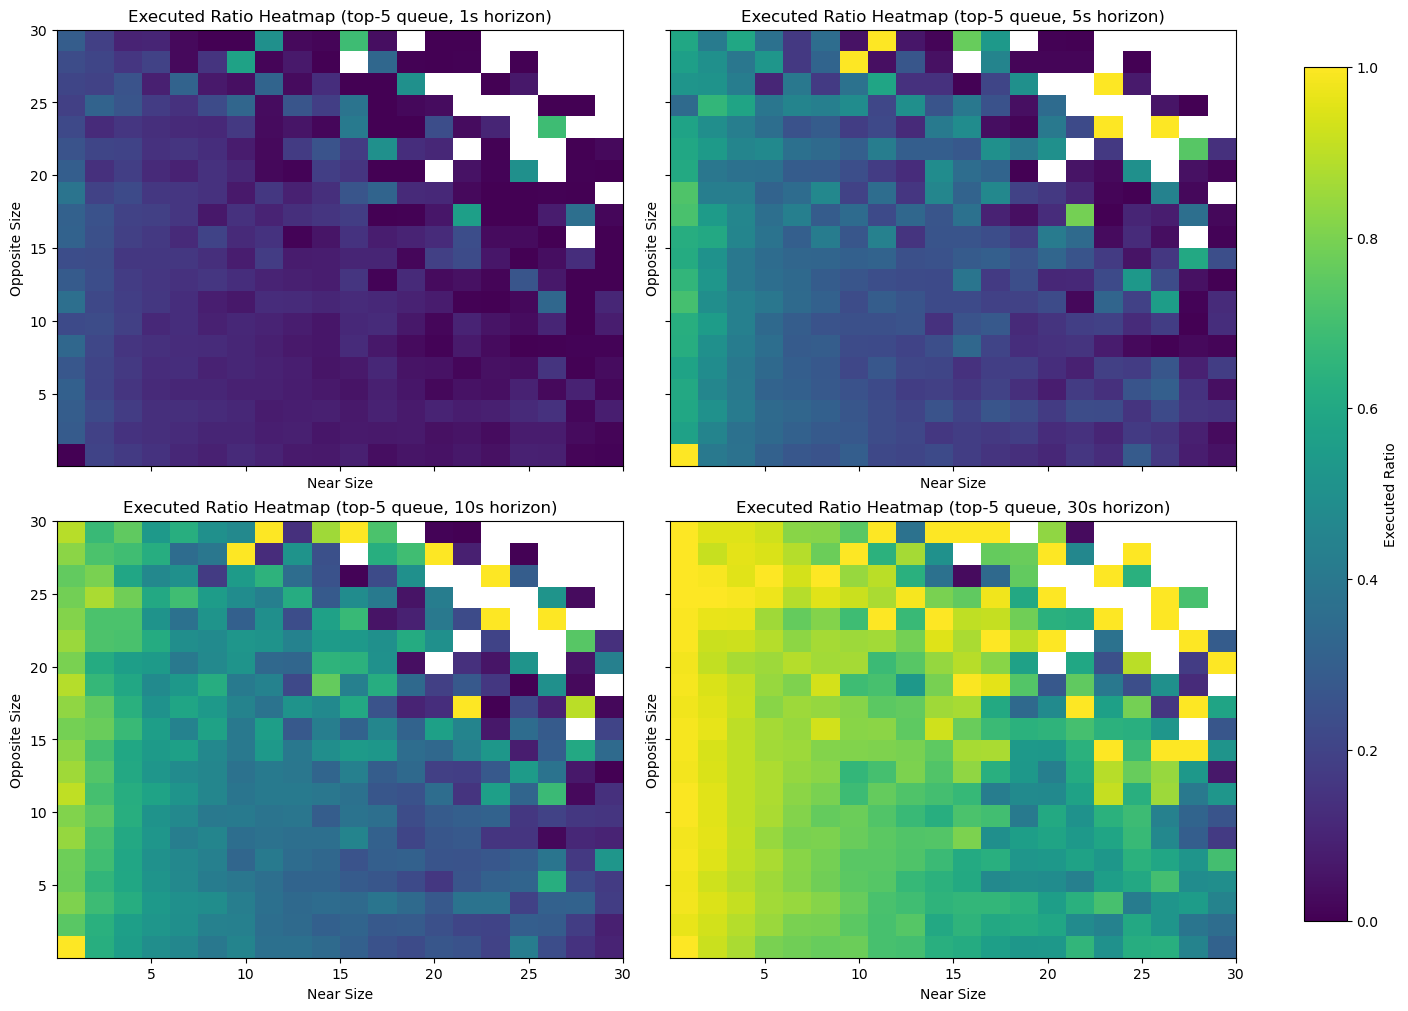

In [9]:
executed_ratio_heatmap_range = (1e-8, 30)
executed_ratio_heatmap_bins = 20
executed_ratio_depth = 5

base_orderbook, base_trade, executed_ratio_heatmaps = sp.plot_executed_ratio_heatmap(
    orderbook_by_window,
    trade_by_window,
    BASE_WINDOW_FOR_CORRELATION,
    PRICE_CHANGE_HORIZONS,
    executed_ratio_depth,
    executed_ratio_heatmap_range,
    executed_ratio_heatmap_bins,
)


### Price Change

This section computes the average future price change conditional on top-level bid size and ask size. The heatmaps suggest:

- Shorter horizons have smaller average price changes, so noise appears to dominate.
- Average price change is related to order book imbalance, which is consistent with the expected market mechanism.
- At longer horizons, the relationship between average price change and the current bid/ask size configuration appears weaker, suggesting that the predictive value of the current imbalance decays over time.


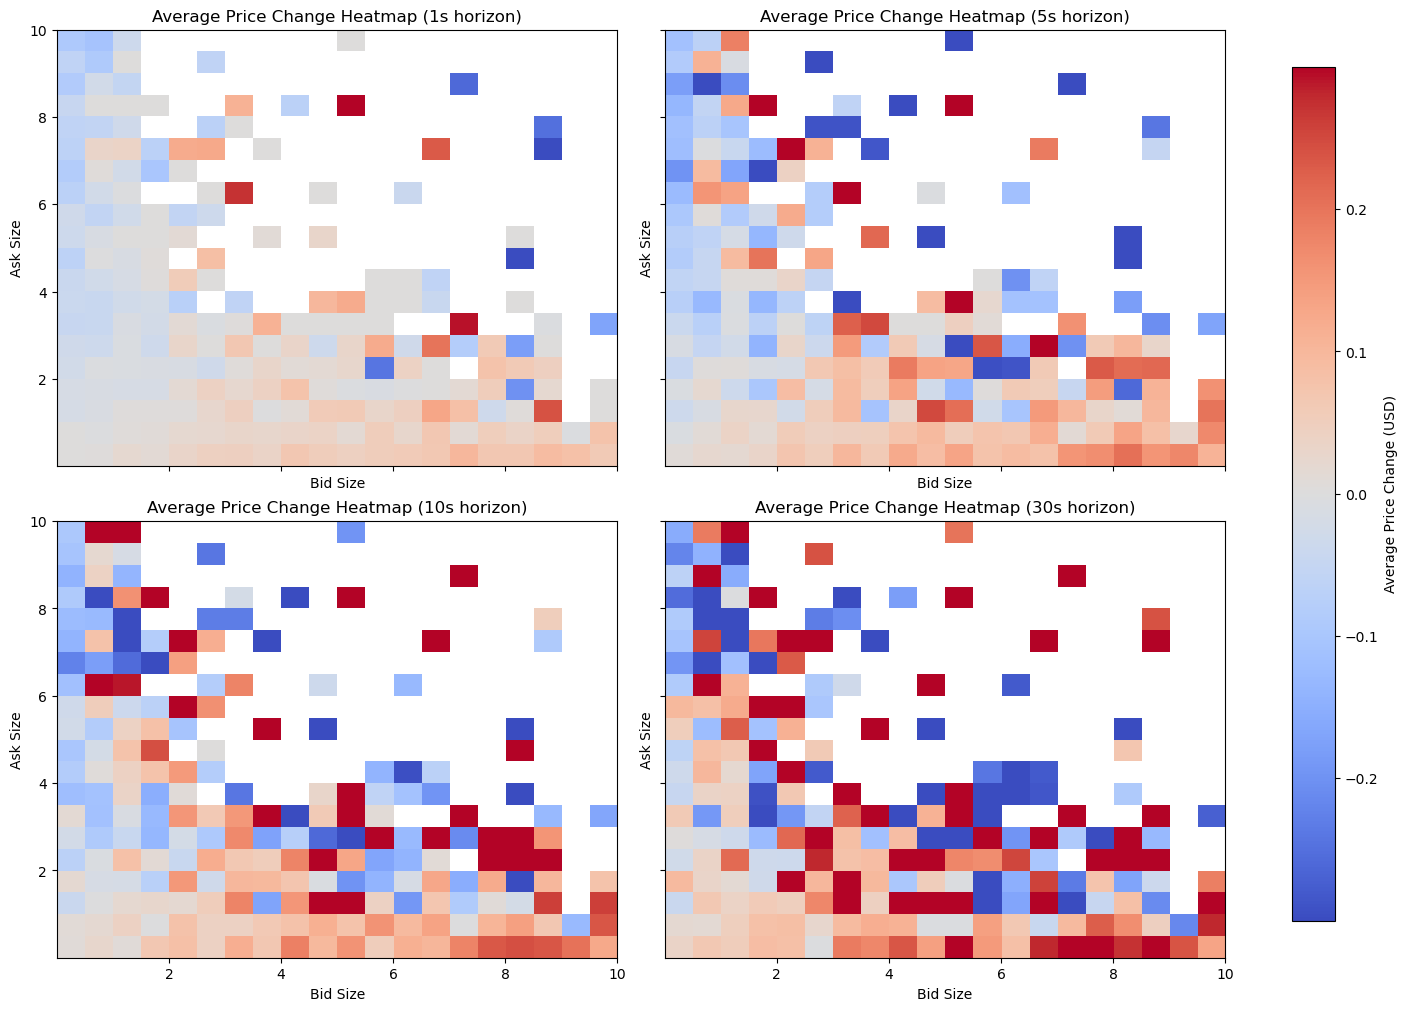

In [10]:
price_change_heatmap_range = (1e-8, 10)
price_change_heatmap_bins = 20
price_change_heatmap_cmap = "coolwarm"
price_change_heatmap_abs_limit = 0.3

avg_price_change_heatmaps, price_change_norm = sp.plot_average_price_change_heatmap(
    base_orderbook,
    price_change_by_horizon,
    PRICE_CHANGE_HORIZONS,
    price_change_heatmap_range,
    price_change_heatmap_bins,
    price_change_heatmap_cmap,
    price_change_heatmap_abs_limit,
)


## Correlation

### Average Fill Volume Per Second

This section computes the correlation between average fill volume per second and spread, near volume, opposite volume, and imbalance across the 1, 5, 10, and 30 second preprocessing windows.

The strongest positive correlations appear on the near-volume row in this sample: when near volume is larger, more volume tends to be filled per second.


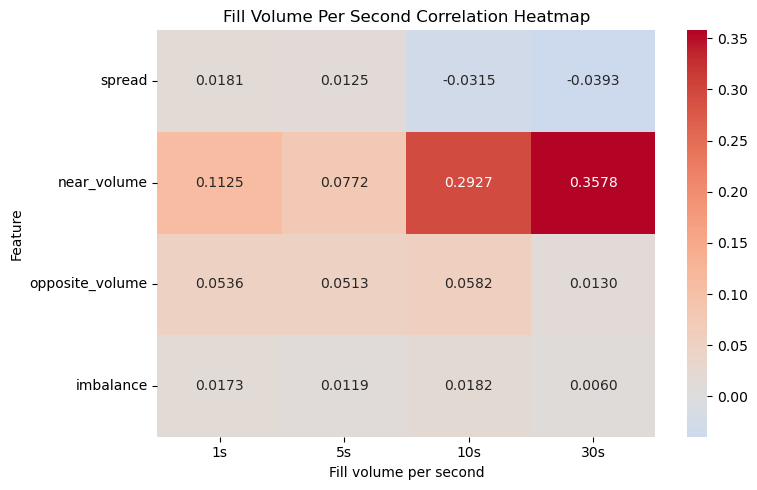

In [11]:
fill_volume_corr_matrix = sp.plot_fill_volume_correlation_heatmap(
    orderbook_by_window,
    trade_by_window,
    ORDERBOOK_WINDOWS,
)


### Cross Correlation

This section computes correlations, for each variance window, among future price changes over X-second horizons, rolling price change variance, depth-summed bid/ask volumes, and depth-based imbalance.

The results suggest:

- price change, variance, imbalance, bid size, and ask size are visibly correlated across horizons and depth levels.
- Imbalance is positively correlated with bid size and negatively correlated with ask size, which is consistent with its definition.
- price change has a modest positive correlation with imbalance, suggesting that imbalance has some predictive signal for future price changes in this sample.


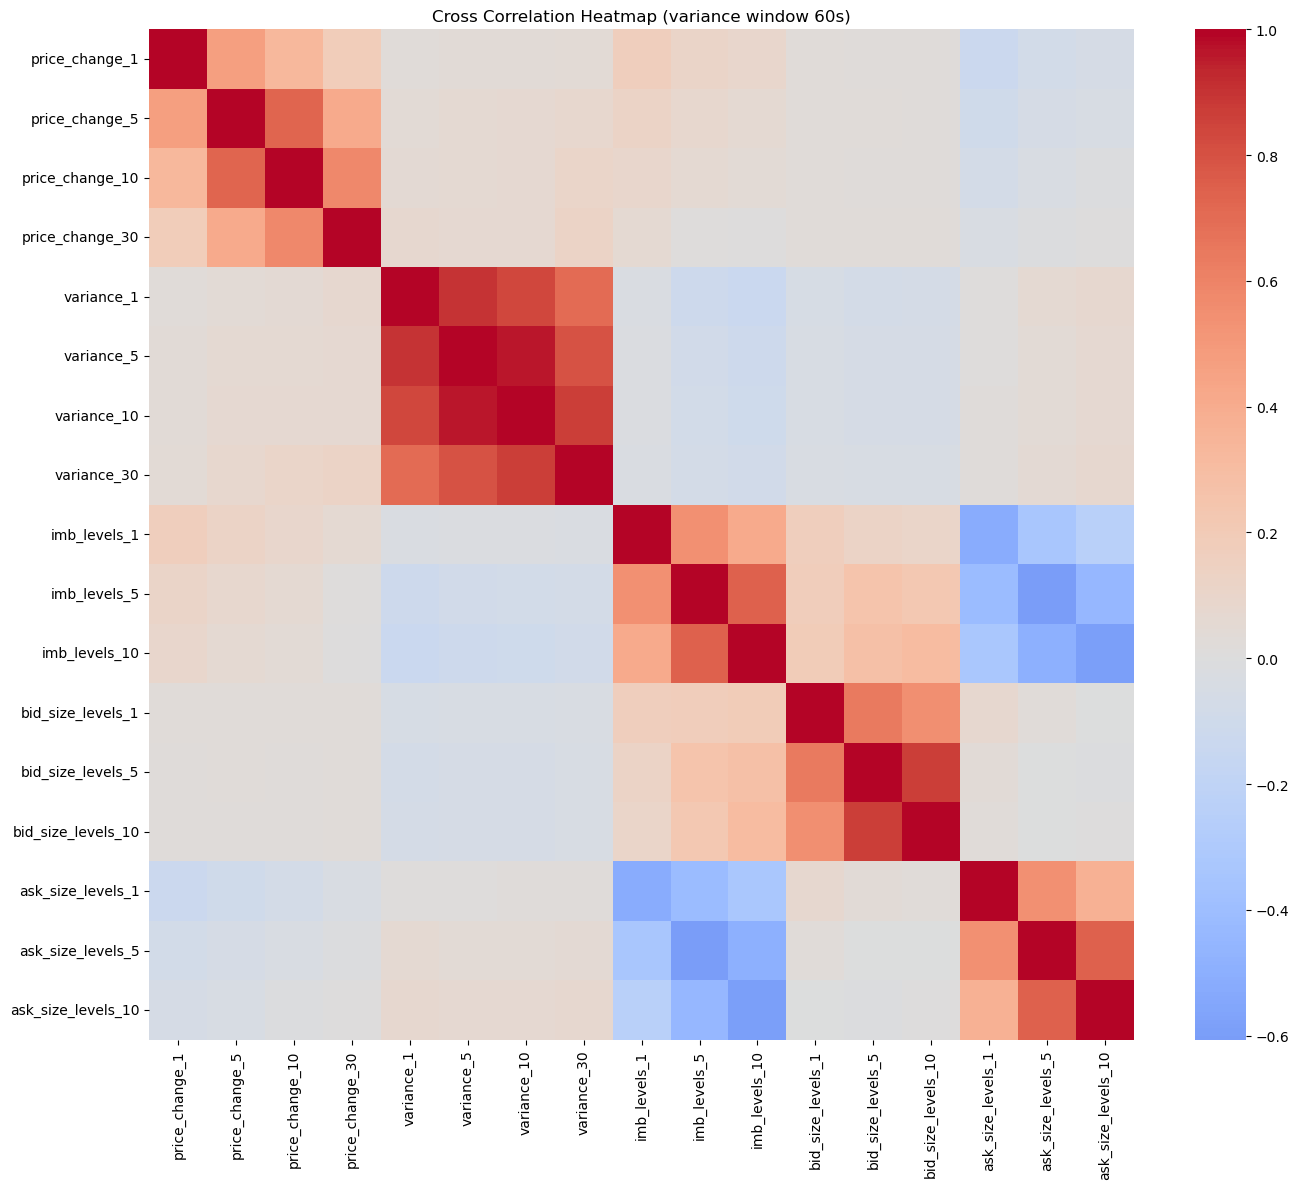

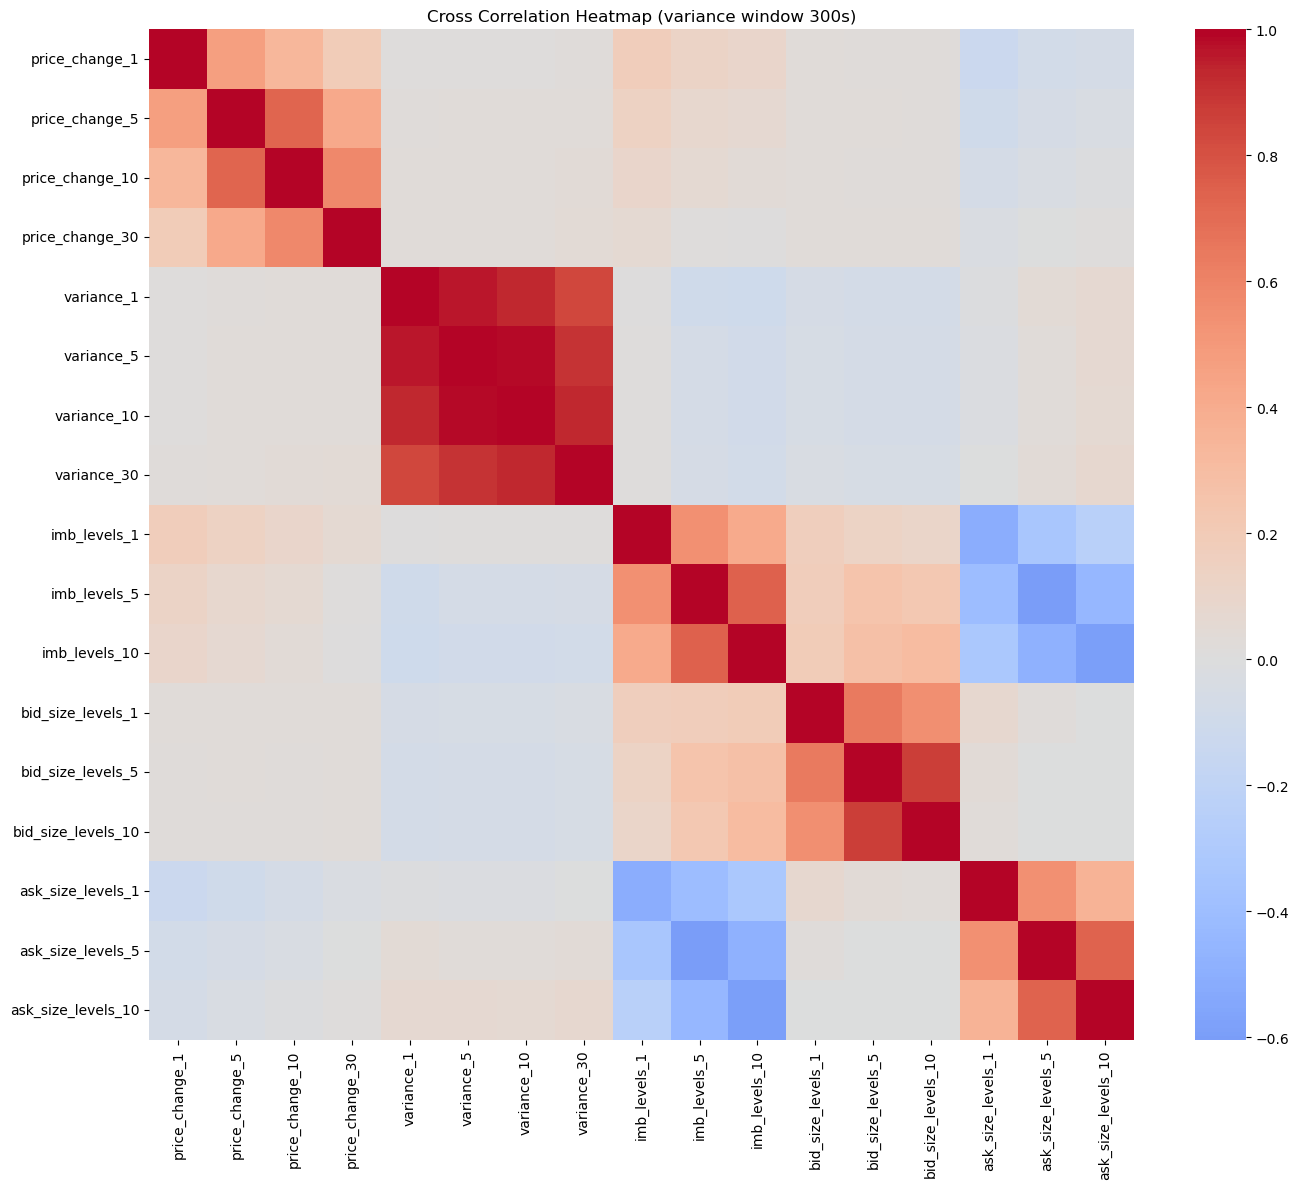

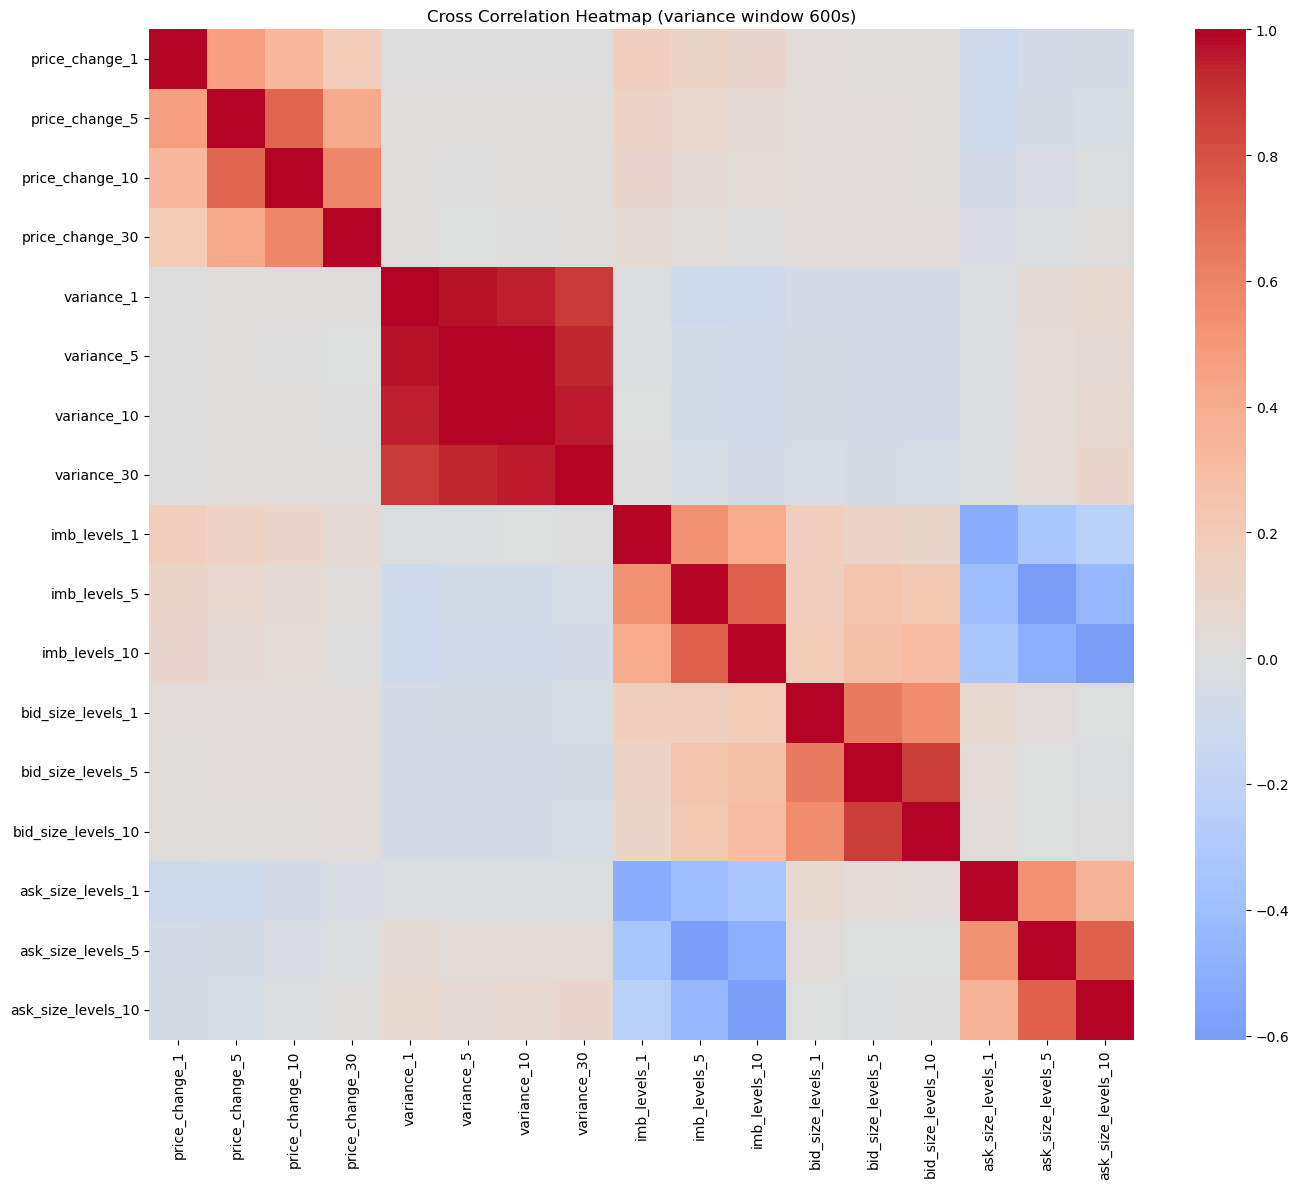

In [12]:
cross_correlation_depths = [1, 5, 10]

cross_correlation_by_variance_window = sp.plot_cross_correlation_heatmap(
    orderbook_by_window,
    BASE_WINDOW_FOR_CORRELATION,
    price_change_by_horizon,
    variance_by_config,
    PRICE_CHANGE_HORIZONS,
    VARIANCE_WINDOWS,
    cross_correlation_depths,
)
